# Hydrogen diffusion along grain boundaries

This tutorial shows how to use FESTIM to simulate hydrogen diffusion in metal microstructures.

We'll show how to generate a microstructure using Voronoi cells, mesh it with GMSH, and solve a transport problem with FESTIM.

## Geometry

### Generating the microstructure

First, we use `scipy` to make a [Voronoi diagram](https://en.wikipedia.org/wiki/Voronoi_diagram) mimicking a microstructure.

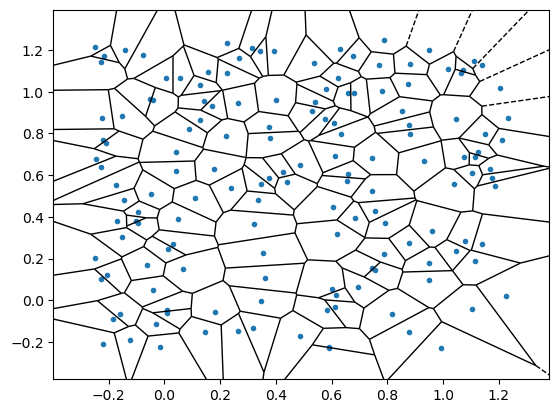

In [ ]:
import numpy as np
from scipy.spatial import Voronoi, voronoi_plot_2d
import matplotlib.pyplot as plt
import gmsh


np.random.seed(1)

# N random seeds in [0,size]x[0,size]
size = 1.5
N_seeds = 150
points = np.random.rand(N_seeds, 2) * size

# centre everything on 0.5, 0.5
points -= size / 2
points += 0.5

vor = Voronoi(points)

voronoi_plot_2d(vor, show_vertices=False, show_points=True)
plt.show()

Now that we have vertices for each voronoi cell, we can use `shapely` to turn them into `shapely.Polygon` objects for easy manipulation.
We then shrink the voronoi cells to make grain boundaries appear. Note that the grain boundary thickness is arbitrary here. 

Number of grains: 79


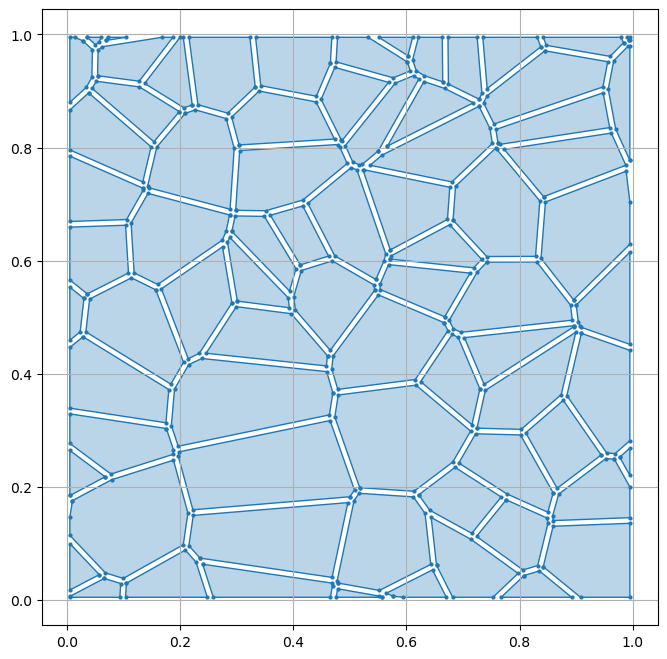

In [29]:
from shapely.geometry import Polygon
from shapely import difference, union_all
from shapely.plotting import plot_polygon, plot_points

gap = 0.01  # thickness of grain boundary

grains = []
for region_idx in vor.point_region:
    region = vor.regions[region_idx]
    if -1 in region or len(region) == 0:
        continue  # skip infinite regions
    poly = Polygon([vor.vertices[i] for i in region])
    poly = poly.intersection(
        Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])
    )  # clip to domain
    if not poly.is_empty:
        grains.append(poly.buffer(-gap / 2))  # shrink each grain inward

print("Number of grains:", len(grains))

plt.figure(figsize=(8, 8))
# plot grains
for polygon in grains:
    plot_polygon(polygon=polygon, add_points=False)
    plot_points(polygon, markersize=2, color="tab:blue")
plt.show()

To make a new `Polygon` for our grain boundaries by substracting all the grains from a square polygon.

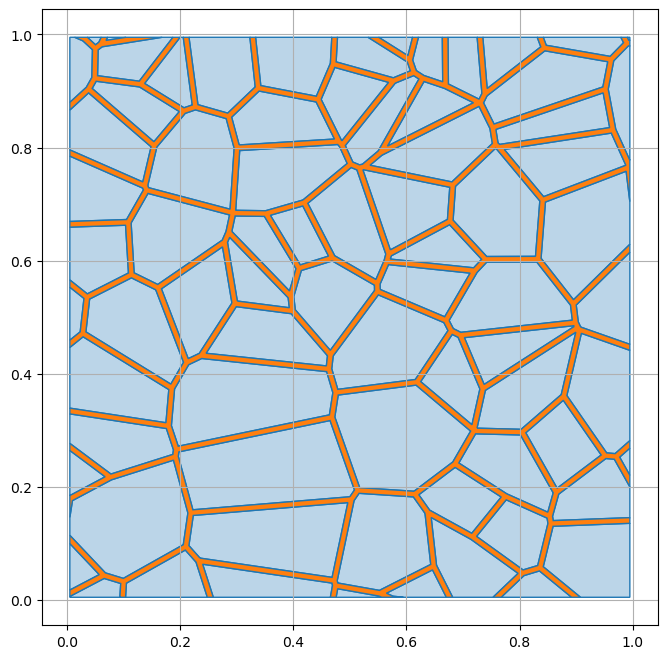

In [30]:
# Grain boundary = everything not covered by grains
eps = gap / 2
domain = Polygon(
    [(0 + eps, 0 + eps), (1 - eps, 0 + eps), (1 - eps, 1 - eps), (0 + eps, 1 - eps)]
)
grain_union = union_all(grains)
grain_boundaries = difference(domain, grain_union)

plt.figure(figsize=(8, 8))
for polygon in grains:
    plot_polygon(polygon=polygon, add_points=False)
plot_polygon(polygon=grain_boundaries, facecolor="tab:orange", add_points=False)
plt.show()

### Mesh with GMSH

We can now pass this geometry to GMSH for meshing. We tag the grains, grain boundaries, and the left and right surfaces as different subdomains. 

In [3]:
gmsh.initialize()
gmsh.model.add("voronoi")

lc = 0.01  # mesh size


def add_polygon_occ(poly):
    """Add polygon using OpenCASCADE kernel for better Boolean operations"""
    if poly.is_empty:
        return []

    # Handle MultiPolygon recursively
    if poly.geom_type == "MultiPolygon":
        surfaces = []
        for p in poly.geoms:
            surfaces.extend(add_polygon_occ(p))
        return surfaces

    # Ensure polygon is valid
    poly = poly.buffer(0)
    if not poly.is_valid:
        return []

    # exterior coords
    coords = list(poly.exterior.coords)[:-1]  # remove duplicate last point
    if len(coords) < 3:
        return []

    # Create wire from points using OCC
    points = []
    for x, y in coords:
        points.append(gmsh.model.occ.addPoint(x, y, 0))

    # Create lines connecting the points
    lines = []
    for i in range(len(points)):
        next_i = (i + 1) % len(points)
        lines.append(gmsh.model.occ.addLine(points[i], points[next_i]))

    # Create curve loop and surface
    wire = gmsh.model.occ.addWire(lines)

    # Handle holes if any
    holes = []
    if len(poly.interiors) > 0:
        for interior in poly.interiors:
            int_coords = list(interior.coords)[:-1]
            if len(int_coords) < 3:
                continue

            # Create hole wire
            hole_points = []
            for x, y in int_coords:
                hole_points.append(gmsh.model.occ.addPoint(x, y, 0))

            hole_lines = []
            for i in range(len(hole_points)):
                next_i = (i + 1) % len(hole_points)
                hole_lines.append(
                    gmsh.model.occ.addLine(hole_points[i], hole_points[next_i])
                )

            hole_wire = gmsh.model.occ.addWire(hole_lines)
            holes.append(hole_wire)

    # Create surface
    if holes:
        surface = gmsh.model.occ.addPlaneSurface([wire] + holes)
    else:
        surface = gmsh.model.occ.addPlaneSurface([wire])

    return [surface]


# Add grains using OCC kernel
grain_surfaces = []
for i, poly in enumerate(grains):
    grain_surfaces.extend(add_polygon_occ(poly))

gb_surfaces = []
if not grain_boundaries.is_empty:
    gb_surfaces.extend(add_polygon_occ(grain_boundaries))

# Synchronize OCC before fragmentation
gmsh.model.occ.synchronize()

# Fragment all surfaces together
gmsh.model.occ.fragment([(2, tag) for tag in grain_surfaces], [(2, gb_surfaces[0])])
gmsh.model.occ.synchronize()

# Create physical groups with all fragmented surfaces

gmsh.model.addPhysicalGroup(2, grain_surfaces, 1, name="grains")
gmsh.model.addPhysicalGroup(2, gb_surfaces, 2, name="grain_boundaries")

# Set mesh size for all points
gmsh.option.setNumber("Mesh.MeshSizeMax", lc)
gmsh.option.setNumber("Mesh.MeshSizeMin", lc)

# find lines on the boundaries
# Get all line entities (dimension = 1)
lines = gmsh.model.getEntities(1)

# List to store the tags of the lines on the boundaries
lines_on_left = []
lines_on_right = []

for line_tag_pair in lines:
    dim = line_tag_pair[0]  # Dimension of the entity (1 for lines)
    tag = line_tag_pair[1]  # Tag of the entity

    # Get the bounding points (dimension = 0) for the current line
    bounding_points = gmsh.model.getBoundary([line_tag_pair])

    # Get the coordinates for each bounding point
    point_coords = []
    for point_tag_pair in bounding_points:
        coords = gmsh.model.getValue(point_tag_pair[0], point_tag_pair[1], [])
        point_coords.append(coords)

    # Check if both bounding points are on the left boundary (x ≈ eps)
    is_on_left = True
    for coords in point_coords:
        x_coord = coords[0]
        if abs(x_coord - eps) > 1e-9:
            is_on_left = False
            break

    # Check if both bounding points are on the right boundary (x ≈ 1-eps)
    is_on_right = True
    for coords in point_coords:
        x_coord = coords[0]
        if abs(x_coord - (1 - eps)) > 1e-9:
            is_on_right = False
            break

    if is_on_left:
        lines_on_left.append(tag)
    if is_on_right:
        lines_on_right.append(tag)

print("Lines on left boundary:", lines_on_left)
print("Lines on right boundary:", lines_on_right)

if lines_on_left:
    gmsh.model.addPhysicalGroup(1, lines_on_left, name="left_boundary")
if lines_on_right:
    gmsh.model.addPhysicalGroup(1, lines_on_right, name="right_boundary")

gmsh.model.mesh.generate(2)
# gmsh.fltk.run()
gmsh.write("voronoi_grains.msh")

gmsh.finalize()

Lines on left boundary: [10, 34, 71, 96, 137, 176, 192, 248, 268, 272, 371, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417]          
Lines on right boundary: [144, 154, 158, 168, 276, 286, 313, 343, 431, 432, 433, 434, 435, 436, 437]
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (Line)
Info    : [ 10%] Meshing curve 10 (Line)
Info    : [ 10%] Meshing curve 11 (Line)
Info    : [ 10%] Meshing curve 12 (Line)
Info    : [ 10%] Meshing curve 13 (Line)
Info    : [ 10%] Meshing curve 14 (Line)
Info    : [ 10%] Meshing curve 15 (Line)
Info    : [ 10%] Meshing curve 16 (Line)
Info    : [ 10%] Meshing curve 17 (Line)
Info    : [ 10%] Meshing curve 18 (Line)
Info    : 

## FESTIM model

We can now define our hydrogen transport problem.

$$
\frac{\partial c}{\partial t} = \nabla \cdot (D \nabla c)
$$

where $D=D_\mathrm{GB}$ and $D=D_\mathrm{grain}$ in the grain boundary and in the grain, respectively.

Boundary conditions:

- $ c = 1 $ on the left surface
- $ c = 0 $ on the right surface

Interface condition:
- We assume continuity of concentration at the GB/grain interfaces.

Simulation time: $t_f = 1.5$

### Convert mesh to dolfinx

In [ ]:
from dolfinx.io import gmshio
from mpi4py import MPI


model_rank = 0
mesh, cell_tags, facet_tags = gmshio.read_from_msh(
    "voronoi_grains.msh", MPI.COMM_WORLD, 0, gdim=2
)

Info    : Reading 'voronoi_grains.msh'...
Info    : 927 entities
Info    : 13269 nodes
Info    : 26318 elements
Info    : Done reading 'voronoi_grains.msh'


In [5]:
from dolfinx import plot
import pyvista

pyvista.start_xvfb()
pyvista.set_jupyter_backend("html")

tdim = mesh.topology.dim

mesh.topology.create_connectivity(tdim, tdim)
fdim = mesh.topology.dim - 1
tdim = mesh.topology.dim
mesh.topology.create_connectivity(fdim, tdim)

topology, cell_types, x = plot.vtk_mesh(mesh, tdim, cell_tags.indices)
p = pyvista.Plotter()
grid = pyvista.UnstructuredGrid(topology, cell_types, x)
grid.cell_data["Cell Marker"] = cell_tags.values
grid.set_active_scalars("Cell Marker")
p.add_mesh(grid, show_edges=False)
if pyvista.OFF_SCREEN:
    figure = p.screenshot("cell_marker.png")
p.show()


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

### Case 1: GBs are more diffusive

In this first case, $D_\mathrm{GB}= 1000 \ D_\mathrm{grain}$

In [ ]:
import festim as F

grain_mat = F.Material(D_0=0.001, E_D=0)
gb_mat = F.Material(D_0=1, E_D=0)


grain_vol = F.VolumeSubdomain(id=1, material=grain_mat)
gb_vol = F.VolumeSubdomain(id=2, material=gb_mat)

left_surf = F.SurfaceSubdomain(id=3)
right_surf = F.SurfaceSubdomain(id=4)

my_model = F.HydrogenTransportProblem()

my_model.mesh = F.Mesh(mesh)

# we need to pass the meshtags to the model directly
my_model.facet_meshtags = facet_tags
my_model.volume_meshtags = cell_tags

my_model.subdomains = [left_surf, right_surf, grain_vol, gb_vol]

H = F.Species("H")
my_model.species = [H]

my_model.temperature = 400

my_model.boundary_conditions = [
    F.FixedConcentrationBC(subdomain=left_surf, value=0, species=H),
    F.FixedConcentrationBC(subdomain=right_surf, value=1, species=H),
]

my_model.settings = F.Settings(atol=1e-10, rtol=1e-20, final_time=1.5)
my_model.settings.stepsize = 0.01

my_model.exports = [F.VTXSpeciesExport(filename="out.bp", field=H)]

my_model.initialise()
my_model.run()

Solving HydrogenTransportProblem:   0%|          | 0.00/1.50 [00:00<?, ?it/s]

At the end of the simulation, we can see on the concentration field the preferential diffusion along the grain boundaries!

In [ ]:
hydrogen_concentration = H.solution

topology, cell_types, geometry = plot.vtk_mesh(hydrogen_concentration.function_space)
u_grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
u_grid.point_data["c"] = hydrogen_concentration.x.array.real
u_grid.set_active_scalars("c")
u_plotter = pyvista.Plotter()
u_plotter.add_mesh(u_grid, show_edges=False)

u_plotter.add_title(f"D_GB/D_grain = {gb_mat.D_0/grain_mat.D_0: .4f}")


if not pyvista.OFF_SCREEN:
    u_plotter.show()
else:
    figure = u_plotter.screenshot("concentration.png")

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

### Case 2: GBs are less diffusive

We can also look at the opposite case with grain boundaries less diffusive the the grain themselves.

In [ ]:
gb_mat.D_0 = 0.1
grain_mat.D_0 = 1

my_model.initialise()
my_model.run()

Solving HydrogenTransportProblem:   0%|          | 0.00/1.50 [00:00<?, ?it/s]

In [ ]:
hydrogen_concentration = H.solution

topology, cell_types, geometry = plot.vtk_mesh(hydrogen_concentration.function_space)
u_grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
u_grid.point_data["c"] = hydrogen_concentration.x.array.real
u_grid.set_active_scalars("c")
u_plotter = pyvista.Plotter()

u_plotter.add_mesh(u_grid, show_edges=False)

u_plotter.add_title(f"D_GB/D_grain = {gb_mat.D_0/grain_mat.D_0: .1f}")

if not pyvista.OFF_SCREEN:
    u_plotter.show()
else:
    figure = u_plotter.screenshot("concentration.png")

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…